In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
from student_env import MathTutorEnv, state_to_index
env = MathTutorEnv()
state = env.reset()
print("Initial state:", state)
next_state, reward, done, info = env.step(0)
print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Initial state: (0, 0)
Next state: (0, 0)
Reward: 1
Done: False
Info: {'correct': np.True_, 'add_skill': np.float64(0.3348261997332984), 'sub_skill': np.float64(0.26418789030121387), 'prob_correct': np.float64(0.24482619973329844)}


In [3]:
from q_learning import train_q_learning
q_table, q_results = train_q_learning()
print(q_table)
print("Average reward in last 100 episodes:", np.mean(q_results["rewards"][-100:]))
print("Average accuracy in last 100 episodes:", np.mean(q_results["accuracy"][-100:]))

[[11.2662566  10.2962744 ]
 [13.87939621 14.46965921]
 [16.08610017 16.65158498]
 [13.80671506 13.02764414]
 [13.91279074 13.59944803]
 [16.25052264 17.2233732 ]
 [16.55966917 15.94028353]
 [15.93886783 15.80588853]
 [15.1734478  13.8248637 ]]
Average reward in last 100 episodes: 17.208000000000002
Average accuracy in last 100 episodes: 0.6446666666666667


In [4]:
from baselines import run_random_baseline, run_weakest_skill_baseline
random_rewards = run_random_baseline()
weakest_rewards = run_weakest_skill_baseline()
print("Q-learning:", np.mean(q_results["rewards"][-100:]))
print("Random:", np.mean(random_rewards))
print("Weakest:", np.mean(weakest_rewards))

Q-learning: 17.208000000000002
Random: 12.672
Weakest: 11.7612


In [5]:
from sarsa import train_sarsa
sarsa_table, sarsa_results = train_sarsa()
print(sarsa_table)
print("SARSA average reward in last 100 episodes:", np.mean(sarsa_results["rewards"][-100:]))
print("SARSA average accuracy in last 100 episodes:", np.mean(sarsa_results["accuracy"][-100:]))

[[10.56775644  9.41496797]
 [12.02830626 12.58838878]
 [14.72173071 15.29805283]
 [11.67841981 11.50778839]
 [13.12366126 13.38741367]
 [15.79737519 16.70492682]
 [15.23996701 14.20558217]
 [15.44113395 14.6412316 ]
 [10.94066245  9.68135003]]
SARSA average reward in last 100 episodes: 18.144
SARSA average accuracy in last 100 episodes: 0.6706666666666666


In [6]:
print("Q-learning:", np.mean(q_results["rewards"][-100:]))
print("SARSA:", np.mean(sarsa_results["rewards"][-100:]))
print("Random:", np.mean(random_rewards))
print("Weakest:", np.mean(weakest_rewards))

Q-learning: 17.208000000000002
SARSA: 18.144
Random: 12.672
Weakest: 11.7612


In [7]:
q_table, q_results = train_q_learning()
sarsa_table, sarsa_results = train_sarsa()
random_rewards = run_random_baseline()
weakest_rewards = run_weakest_skill_baseline()

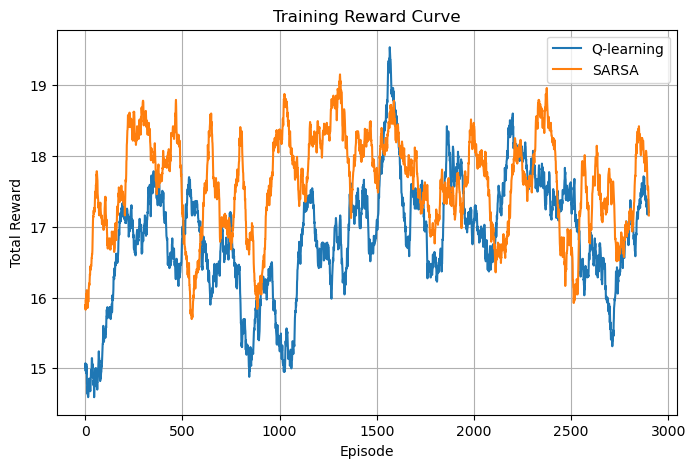

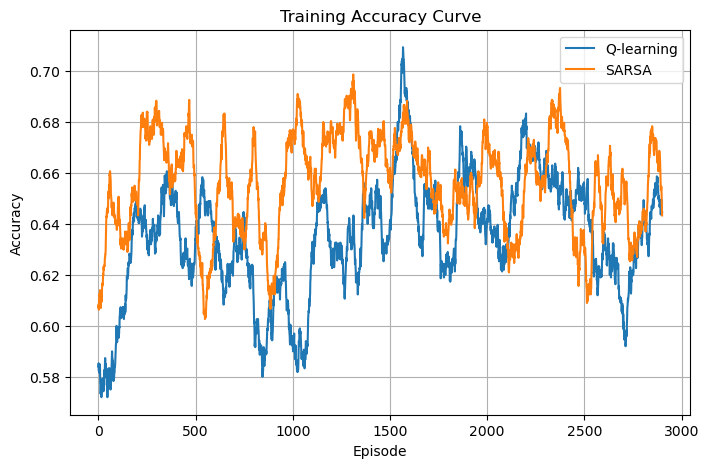

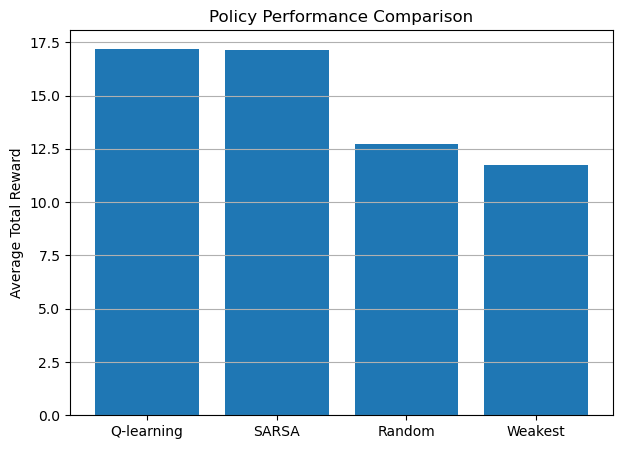

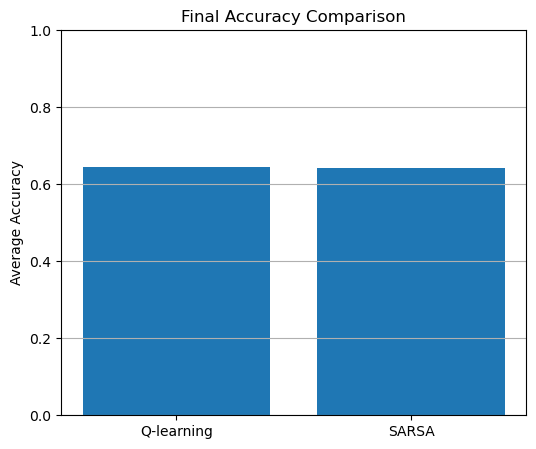


Learned Policy: Q-learning
----------------------------------------
Addition: Low, Subtraction: Low -> Choose Addition
Addition: Low, Subtraction: Medium -> Choose Subtraction
Addition: Low, Subtraction: High -> Choose Subtraction
Addition: Medium, Subtraction: Low -> Choose Addition
Addition: Medium, Subtraction: Medium -> Choose Subtraction
Addition: Medium, Subtraction: High -> Choose Subtraction
Addition: High, Subtraction: Low -> Choose Addition
Addition: High, Subtraction: Medium -> Choose Addition
Addition: High, Subtraction: High -> Choose Subtraction

Learned Policy: SARSA
----------------------------------------
Addition: Low, Subtraction: Low -> Choose Subtraction
Addition: Low, Subtraction: Medium -> Choose Subtraction
Addition: Low, Subtraction: High -> Choose Subtraction
Addition: Medium, Subtraction: Low -> Choose Addition
Addition: Medium, Subtraction: Medium -> Choose Addition
Addition: Medium, Subtraction: High -> Choose Subtraction
Addition: High, Subtraction: Low -

In [13]:
from evaluation import (
    plot_training_rewards,
    plot_training_accuracy,
    plot_policy_comparison,
    plot_accuracy_comparison,
    print_learned_policy
)

# 1. RL training curves
plot_training_rewards(q_results, sarsa_results)
plot_training_accuracy(q_results, sarsa_results)

# 2. RL vs Baseline comparison
plot_policy_comparison(
    q_results,
    sarsa_results,
    random_rewards,
    weakest_rewards
)

# 3. Accuracy comparison between RL models
plot_accuracy_comparison(q_results, sarsa_results)

# 4. Print learned policies
print_learned_policy(q_table, "Q-learning")
print_learned_policy(sarsa_table, "SARSA")